4. [20 points] Training on the 2D Gaussian Mixture Ring
(a) [10 points] List all the parameters used in your critic and generator networks including number of layers,
type of layers, wdith of each layer, and activ

In [ ]:
# ============================================================
# HW3 - Problem 4(a)
# Network definitions for Vanilla GAN and WGAN on 2D Ring
# This code is intentionally written so it can be reused for:
#   4(b) training
#   4(c) WGAN with Adam comparison
#   5(a) sample scatter + KDE plots
#   5(b) mode coverage
#   5(c) training stability discussion
# ============================================================

import math
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# -----------------------------
# Device
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ============================================================
# DATASET: 8-Gaussian ring in 2D
# Reusable for Problems 4 and 5
# ============================================================
class GaussianRingDataset(Dataset):
    def __init__(self, n_samples=50000, radius=1.0, variance=25e-4, n_modes=8, seed=42):
        """
        n_samples : total number of samples
        radius    : radius of the ring
        variance  : variance of each Gaussian = 25 x 10^-4
        n_modes   : number of Gaussian modes (8)
        """
        super().__init__()
        rng = np.random.default_rng(seed)

        self.n_samples = n_samples
        self.radius = radius
        self.variance = variance
        self.std = math.sqrt(variance)
        self.n_modes = n_modes

        # equally spaced mode centers on unit circle
        angles = np.linspace(0, 2 * np.pi, n_modes, endpoint=False)
        self.centers = np.stack(
            [radius * np.cos(angles), radius * np.sin(angles)],
            axis=1
        ).astype(np.float32)

        # choose a mode for each sample uniformly
        mode_ids = rng.integers(0, n_modes, size=n_samples)
        means = self.centers[mode_ids]

        # sample from Gaussian around each center
        noise = rng.normal(loc=0.0, scale=self.std, size=(n_samples, 2)).astype(np.float32)
        self.samples = means + noise

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        return torch.tensor(self.samples[idx], dtype=torch.float32)


def get_dataloader(batch_size=128, n_samples=50000, seed=42):
    dataset = GaussianRingDataset(
        n_samples=n_samples,
        radius=1.0,
        variance=25e-4,
        n_modes=8,
        seed=seed
    )
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    return dataset, loader


# ============================================================
# GENERATOR
# Input : z in R^2
# Output: generated point in R^2
#
# Parameters used:
#   Layer 1: Linear(2, 128), LeakyReLU(0.2)
#   Layer 2: Linear(128, 128), LeakyReLU(0.2)
#   Layer 3: Linear(128, 2)
# ============================================================
class Generator(nn.Module):
    def __init__(self, z_dim=2, hidden_dim=128, out_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, hidden_dim),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, z):
        return self.net(z)


# ============================================================
# DISCRIMINATOR for Vanilla GAN
# Input : x in R^2
# Output: probability in [0,1]
#
# Parameters used:
#   Layer 1: Linear(2, 128), LeakyReLU(0.2)
#   Layer 2: Linear(128, 128), LeakyReLU(0.2)
#   Layer 3: Linear(128, 1), Sigmoid
# ============================================================
class Discriminator(nn.Module):
    def __init__(self, in_dim=2, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


# ============================================================
# CRITIC for WGAN
# Input : x in R^2
# Output: real-valued score
#
# Same as discriminator, but WITHOUT sigmoid
# ============================================================
class Critic(nn.Module):
    def __init__(self, in_dim=2, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.net(x)


# ============================================================
# Helper: sample latent noise
# ============================================================
def sample_noise(batch_size, z_dim=2, device=device):
    return torch.randn(batch_size, z_dim, device=device)


# ============================================================
# Print architecture summary for Problem 4(a)
# ============================================================
def print_model_details():
    print("=" * 70)
    print("Problem 4(a): Network Parameters")
    print("=" * 70)

    print("\nGenerator:")
    print("  Input dimension       : 2")
    print("  Number of layers      : 3 fully connected (Linear) layers")
    print("  Layer widths          : 2 -> 128 -> 128 -> 2")
    print("  Hidden activations    : LeakyReLU(0.2)")
    print("  Output activation     : None")
    print("  Output meaning        : 2D generated sample")

    print("\nVanilla GAN Discriminator:")
    print("  Input dimension       : 2")
    print("  Number of layers      : 3 fully connected (Linear) layers")
    print("  Layer widths          : 2 -> 128 -> 128 -> 1")
    print("  Hidden activations    : LeakyReLU(0.2)")
    print("  Output activation     : Sigmoid")
    print("  Output meaning        : Probability that sample is real")

    print("\nWGAN Critic:")
    print("  Input dimension       : 2")
    print("  Number of layers      : 3 fully connected (Linear) layers")
    print("  Layer widths          : 2 -> 128 -> 128 -> 1")
    print("  Hidden activations    : LeakyReLU(0.2)")
    print("  Output activation     : None")
    print("  Output meaning        : Real-valued critic score")

    print("\nTraining-related defaults for later parts:")
    print("  Dataset               : 50,000 samples from 8 Gaussians on unit circle")
    print("  Variance              : 25e-4")
    print("  Batch size            : 128")
    print("  Vanilla GAN optimizer : Adam, lr = 1e-4")
    print("  WGAN optimizer        : RMSProp, lr chosen later in 4(b)")
    print("=" * 70)


# ============================================================
# Main test block
# ============================================================
if __name__ == "__main__":
    # dataset + loader
    dataset, loader = get_dataloader(batch_size=128, n_samples=50000, seed=42)

    # instantiate models
    G = Generator().to(device)
    D = Discriminator().to(device)
    C = Critic().to(device)

    # print architecture info for writeup
    print_model_details()

    # quick shape test
    real_batch = next(iter(loader)).to(device)
    z = sample_noise(real_batch.size(0), z_dim=2, device=device)
    fake_batch = G(z)

    print("\nQuick shape check:")
    print("  Real batch shape      :", real_batch.shape)
    print("  Noise batch shape     :", z.shape)
    print("  Fake batch shape      :", fake_batch.shape)
    print("  D(fake) shape         :", D(fake_batch).shape)
    print("  C(fake) shape         :", C(fake_batch).shape)

Problem 4(a): Network Parameters

Generator:
  Input dimension       : 2
  Number of layers      : 3 fully connected (Linear) layers
  Layer widths          : 2 -> 128 -> 128 -> 2
  Hidden activations    : LeakyReLU(0.2)
  Output activation     : None
  Output meaning        : 2D generated sample

Vanilla GAN Discriminator:
  Input dimension       : 2
  Number of layers      : 3 fully connected (Linear) layers
  Layer widths          : 2 -> 128 -> 128 -> 1
  Hidden activations    : LeakyReLU(0.2)
  Output activation     : Sigmoid
  Output meaning        : Probability that sample is real

WGAN Critic:
  Input dimension       : 2
  Number of layers      : 3 fully connected (Linear) layers
  Layer widths          : 2 -> 128 -> 128 -> 1
  Hidden activations    : LeakyReLU(0.2)
  Output activation     : None
  Output meaning        : Real-valued critic score

Training-related defaults for later parts:
  Dataset               : 50,000 samples from 8 Gaussians on unit circle
  Variance       

Report 4(a)

For this homework, I changed the model setup from the paper so it would fit the 2D Gaussian mixture ring dataset instead of an image-generation problem. Since the dataset here is just made of 2D points, using a large image-based network would have been unnecessary. Because of that, I used simple fully connected networks and kept the general training idea from the paper, but adjusted the architecture to match this smaller problem.



In the code, the generator takes a 2D Gaussian noise vector as input and passes it through three linear layers with sizes 2 to 128 → 128 → 2. The hidden layers use LeakyReLU(0.2), and the final layer has no activation because the output is just a 2D point.



For the vanilla GAN, the discriminator also uses three linear layers with sizes 2 → 128 → 128 → 1. The hidden layers again use LeakyReLU(0.2), and the last layer uses a Sigmoid so the output can be interpreted as the probability that the sample is real. For the WGAN, I used the same general network structure for the critic, but removed the final Sigmoid layer so that it outputs a real-valued score instead of a probability. This was the main change needed to make the paper’s approach work for this simpler 2D ring experiment.

(b) [10 points] Train both GANs for 300 epochs using the Adam optimizer with a learning rate of 10−4
for
the vanilla GAN and with the RMSProp method and appropriately chosen learning rate for WGAN (refer
to the paper and their implementation, if available (typically implementations are only made available for
large datasets). Include a plot of the training loss as a function of epochs. This section will be graded
based on attached code which includes the network design in the homework document with appropriate
comments.

Using device: cuda
[Vanilla GAN] Epoch [1/300] | D loss: 1.3644 | G loss: 0.7006
[Vanilla GAN] Epoch [25/300] | D loss: 1.3631 | G loss: 0.7125
[Vanilla GAN] Epoch [50/300] | D loss: 1.3660 | G loss: 0.7126
[Vanilla GAN] Epoch [75/300] | D loss: 1.3684 | G loss: 0.7134
[Vanilla GAN] Epoch [100/300] | D loss: 1.3698 | G loss: 0.7129
[Vanilla GAN] Epoch [125/300] | D loss: 1.3707 | G loss: 0.7129
[Vanilla GAN] Epoch [150/300] | D loss: 1.3716 | G loss: 0.7118
[Vanilla GAN] Epoch [175/300] | D loss: 1.3717 | G loss: 0.7138
[Vanilla GAN] Epoch [200/300] | D loss: 1.3725 | G loss: 0.7142
[Vanilla GAN] Epoch [225/300] | D loss: 1.3733 | G loss: 0.7145
[Vanilla GAN] Epoch [250/300] | D loss: 1.3735 | G loss: 0.7147
[Vanilla GAN] Epoch [275/300] | D loss: 1.3738 | G loss: 0.7119
[Vanilla GAN] Epoch [300/300] | D loss: 1.3748 | G loss: 0.7133
[WGAN] Epoch [1/300] | Critic loss: -0.0001 | G loss: -0.0102
[WGAN] Epoch [25/300] | Critic loss: -0.0001 | G loss: -0.0097
[WGAN] Epoch [50/300] | Criti

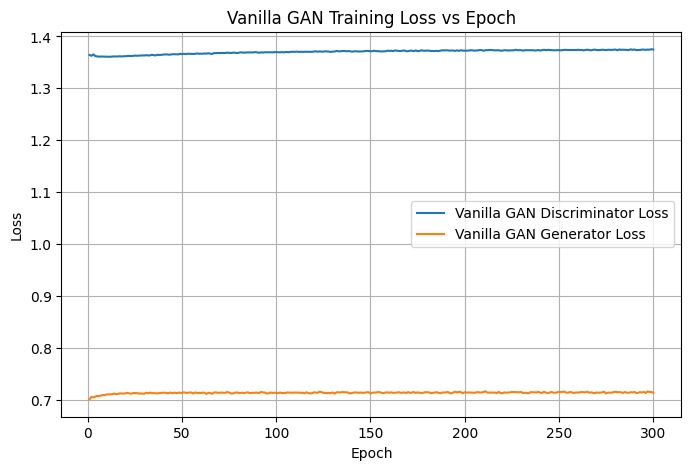

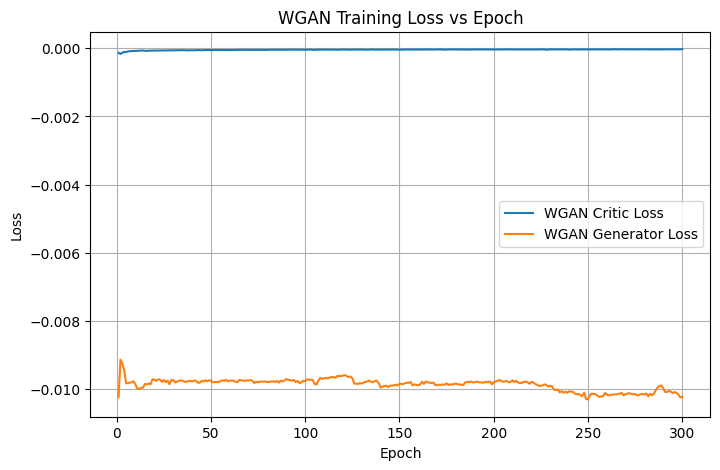

In [ ]:
# ============================================================
# HW3 - Problem 4(b)
# Train Vanilla GAN and WGAN on the 2D Gaussian Mixture Ring
# ============================================================

import math
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# -----------------------------
# Device
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -----------------------------
# Reproducibility
# -----------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# ============================================================
# DATASET: 8 Gaussians equally spaced on a unit circle
# variance = 25 x 10^-4
# ============================================================
class GaussianRingDataset(Dataset):
    def __init__(self, n_samples=50000, radius=1.0, variance=25e-4, n_modes=8, seed=42):
        super().__init__()
        rng = np.random.default_rng(seed)

        self.n_samples = n_samples
        self.radius = radius
        self.variance = variance
        self.std = math.sqrt(variance)
        self.n_modes = n_modes

        # True mode centers on the unit circle
        angles = np.linspace(0, 2 * np.pi, n_modes, endpoint=False)
        self.centers = np.stack(
            [radius * np.cos(angles), radius * np.sin(angles)],
            axis=1
        ).astype(np.float32)

        # Sample modes uniformly
        mode_ids = rng.integers(0, n_modes, size=n_samples)
        means = self.centers[mode_ids]

        # Add Gaussian noise around each center
        noise = rng.normal(0.0, self.std, size=(n_samples, 2)).astype(np.float32)
        self.samples = means + noise

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        return torch.tensor(self.samples[idx], dtype=torch.float32)


def get_dataloader(batch_size=128, n_samples=50000, seed=42):
    dataset = GaussianRingDataset(
        n_samples=n_samples,
        radius=1.0,
        variance=25e-4,
        n_modes=8,
        seed=seed
    )
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    return dataset, loader

# ============================================================
# MODELS
# Generator:     2 -> 128 -> 128 -> 2
# Discriminator: 2 -> 128 -> 128 -> 1 + Sigmoid
# Critic:        2 -> 128 -> 128 -> 1
# ============================================================
class Generator(nn.Module):
    def __init__(self, z_dim=2, hidden_dim=128, out_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, hidden_dim),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self, in_dim=2, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


class Critic(nn.Module):
    def __init__(self, in_dim=2, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.net(x)


def sample_noise(batch_size, z_dim=2, device=device):
    return torch.randn(batch_size, z_dim, device=device)

# ============================================================
# TRAINING: VANILLA GAN
# Adam optimizer, learning rate = 1e-4, 300 epochs
# ============================================================
def train_vanilla_gan(
    epochs=300,
    batch_size=128,
    lr=1e-4,
    z_dim=2,
    n_samples=50000,
    seed=42
):
    set_seed(seed)
    dataset, loader = get_dataloader(batch_size=batch_size, n_samples=n_samples, seed=seed)

    G = Generator(z_dim=z_dim).to(device)
    D = Discriminator().to(device)

    criterion = nn.BCELoss()
    g_opt = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
    d_opt = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

    g_losses = []
    d_losses = []

    for epoch in range(epochs):
        epoch_g_loss = 0.0
        epoch_d_loss = 0.0
        num_batches = 0

        for real in loader:
            real = real.to(device)
            batch_size_curr = real.size(0)

            real_labels = torch.ones(batch_size_curr, 1, device=device)
            fake_labels = torch.zeros(batch_size_curr, 1, device=device)

            # -------------------------
            # Train discriminator
            # -------------------------
            d_opt.zero_grad()

            real_out = D(real)
            d_real_loss = criterion(real_out, real_labels)

            z = sample_noise(batch_size_curr, z_dim=z_dim, device=device)
            fake = G(z)
            fake_out = D(fake.detach())
            d_fake_loss = criterion(fake_out, fake_labels)

            d_loss = d_real_loss + d_fake_loss
            d_loss.backward()
            d_opt.step()

            # -------------------------
            # Train generator
            # -------------------------
            g_opt.zero_grad()

            z = sample_noise(batch_size_curr, z_dim=z_dim, device=device)
            fake = G(z)
            fake_out = D(fake)

            # Generator tries to make fake samples classified as real
            g_loss = criterion(fake_out, real_labels)
            g_loss.backward()
            g_opt.step()

            epoch_d_loss += d_loss.item()
            epoch_g_loss += g_loss.item()
            num_batches += 1

        epoch_d_loss /= num_batches
        epoch_g_loss /= num_batches

        d_losses.append(epoch_d_loss)
        g_losses.append(epoch_g_loss)

        if (epoch + 1) % 25 == 0 or epoch == 0:
            print(f"[Vanilla GAN] Epoch [{epoch+1}/{epochs}] | D loss: {epoch_d_loss:.4f} | G loss: {epoch_g_loss:.4f}")

    return G, D, g_losses, d_losses, dataset

# ============================================================
# TRAINING: WGAN
# RMSProp optimizer, learning rate = 5e-5
# 5 critic updates per generator update
# weight clipping = 0.01
# These settings worked for the current 2D ring experiment.
# ============================================================
def train_wgan(
    epochs=300,
    batch_size=128,
    lr=5e-5,
    z_dim=2,
    n_samples=50000,
    seed=42,
    n_critic=5,
    clip_value=0.01
):
    set_seed(seed)
    dataset, loader = get_dataloader(batch_size=batch_size, n_samples=n_samples, seed=seed)

    G = Generator(z_dim=z_dim).to(device)
    C = Critic().to(device)

    g_opt = torch.optim.RMSprop(G.parameters(), lr=lr)
    c_opt = torch.optim.RMSprop(C.parameters(), lr=lr)

    g_losses = []
    c_losses = []

    for epoch in range(epochs):
        epoch_g_loss = 0.0
        epoch_c_loss = 0.0
        num_batches = 0

        for real in loader:
            real = real.to(device)
            batch_size_curr = real.size(0)

            # -------------------------
            # Train critic
            # -------------------------
            for _ in range(n_critic):
                c_opt.zero_grad()

                z = sample_noise(batch_size_curr, z_dim=z_dim, device=device)
                fake = G(z).detach()

                c_real = C(real)
                c_fake = C(fake)

                # WGAN critic loss to minimize:
                # -(E[C(real)] - E[C(fake)])
                c_loss = -(torch.mean(c_real) - torch.mean(c_fake))
                c_loss.backward()
                c_opt.step()

                # Weight clipping as in original WGAN-style training
                for p in C.parameters():
                    p.data.clamp_(-clip_value, clip_value)

            # -------------------------
            # Train generator
            # -------------------------
            g_opt.zero_grad()

            z = sample_noise(batch_size_curr, z_dim=z_dim, device=device)
            fake = G(z)
            g_loss = -torch.mean(C(fake))
            g_loss.backward()
            g_opt.step()

            epoch_c_loss += c_loss.item()
            epoch_g_loss += g_loss.item()
            num_batches += 1

        epoch_c_loss /= num_batches
        epoch_g_loss /= num_batches

        c_losses.append(epoch_c_loss)
        g_losses.append(epoch_g_loss)

        if (epoch + 1) % 25 == 0 or epoch == 0:
            print(f"[WGAN] Epoch [{epoch+1}/{epochs}] | Critic loss: {epoch_c_loss:.4f} | G loss: {epoch_g_loss:.4f}")

    return G, C, g_losses, c_losses, dataset

# ============================================================
# PLOTTING
# ============================================================
def plot_training_losses(vanilla_g_losses, vanilla_d_losses, wgan_g_losses, wgan_c_losses):
    epochs = np.arange(1, len(vanilla_g_losses) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, vanilla_d_losses, label="Vanilla GAN Discriminator Loss")
    plt.plot(epochs, vanilla_g_losses, label="Vanilla GAN Generator Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Vanilla GAN Training Loss vs Epoch")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, wgan_c_losses, label="WGAN Critic Loss")
    plt.plot(epochs, wgan_g_losses, label="WGAN Generator Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("WGAN Training Loss vs Epoch")
    plt.legend()
    plt.grid(True)
    plt.show()

# ============================================================
# RUN BOTH TRAININGS
# ============================================================
vanilla_G, vanilla_D, vanilla_g_losses, vanilla_d_losses, dataset = train_vanilla_gan(
    epochs=300,
    batch_size=128,
    lr=1e-4,
    z_dim=2,
    n_samples=50000,
    seed=42
)

wgan_G, wgan_C, wgan_g_losses, wgan_c_losses, _ = train_wgan(
    epochs=300,
    batch_size=128,
    lr=5e-5,        # chosen RMSProp learning rate for the 2D ring experiment
    z_dim=2,
    n_samples=50000,
    seed=42,
    n_critic=5,     # multiple critic updates per generator update in WGAN
    clip_value=0.01 # weight clipping as requested / standard WGAN setup
)

plot_training_losses(
    vanilla_g_losses,
    vanilla_d_losses,
    wgan_g_losses,
    wgan_c_losses
)

In [ ]:
# ============================================================
# HELPERS FOR 4(c), 5(a), 5(b), 5(c)
# ============================================================

def generate_samples(G, n_samples=5000, z_dim=2):
    G.eval()
    with torch.no_grad():
        z = torch.randn(n_samples, z_dim, device=device)
        samples = G(z).cpu().numpy()
    return samples


def get_true_centers(radius=1.0, n_modes=8):
    angles = np.linspace(0, 2*np.pi, n_modes, endpoint=False)
    centers = np.stack([radius*np.cos(angles), radius*np.sin(angles)], axis=1)
    return centers


def plot_generated_scatter(samples, centers=None, title="Generated Samples"):
    plt.figure(figsize=(6, 6))
    plt.scatter(samples[:, 0], samples[:, 1], s=5, alpha=0.5, label="Generated")
    if centers is not None:
        plt.scatter(centers[:, 0], centers[:, 1], s=100, marker='x', label="True centers")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.legend()
    plt.axis("equal")
    plt.grid(True)
    plt.show()


def plot_generated_kde(samples, title="Generated Sample KDE"):
    plt.figure(figsize=(6, 6))
    plt.hist2d(samples[:, 0], samples[:, 1], bins=100, density=True)
    plt.colorbar(label="Density")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.axis("equal")
    plt.show()


def compute_mode_coverage(samples, centers, threshold=0.10):
    """
    Counts how many of the 8 modes are covered.
    A mode is counted as covered if at least one generated sample lies
    within 'threshold' Euclidean distance of that true center.
    """
    covered = 0
    for c in centers:
        dists = np.linalg.norm(samples - c, axis=1)
        if np.any(dists < threshold):
            covered += 1
    return covered

===== WGAN DIAGNOSTICS =====
C(real) mean: 0.010179
C(fake) mean: 0.010166
C(real)-C(fake): 0.000013

Fake sample stats:
x mean/std: -0.076844 / 0.705010
y mean/std: -0.033644 / 0.708458
radius mean/std: 0.997644 / 0.103415

Critic parameter stats:
min: -0.010000
max: 0.010000
mean abs: 0.008876


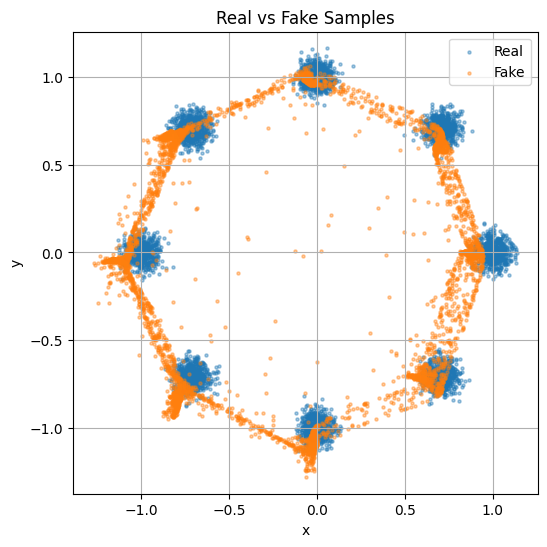

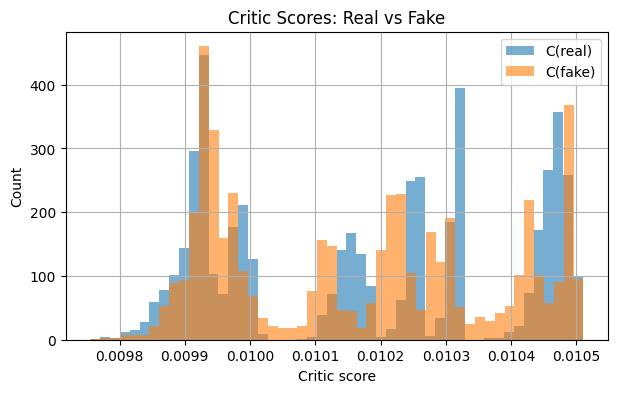

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def diagnose_wgan(G, C, dataset, n_samples=5000, z_dim=2, device=device):
    G.eval()
    C.eval()

    # ----- real samples -----
    real_np = dataset.samples[:n_samples]
    real = torch.tensor(real_np, dtype=torch.float32, device=device)

    # ----- fake samples -----
    with torch.no_grad():
        z = torch.randn(n_samples, z_dim, device=device)
        fake = G(z)
        fake_np = fake.cpu().numpy()

        c_real = C(real).cpu().numpy().flatten()
        c_fake = C(fake).cpu().numpy().flatten()

    print("===== WGAN DIAGNOSTICS =====")
    print(f"C(real) mean: {c_real.mean():.6f}")
    print(f"C(fake) mean: {c_fake.mean():.6f}")
    print(f"C(real)-C(fake): {(c_real.mean() - c_fake.mean()):.6f}")
    print()

    print("Fake sample stats:")
    print(f"x mean/std: {fake_np[:,0].mean():.6f} / {fake_np[:,0].std():.6f}")
    print(f"y mean/std: {fake_np[:,1].mean():.6f} / {fake_np[:,1].std():.6f}")
    print(f"radius mean/std: {np.linalg.norm(fake_np, axis=1).mean():.6f} / {np.linalg.norm(fake_np, axis=1).std():.6f}")
    print()

    # parameter range of critic after clipping
    all_params = []
    for p in C.parameters():
        all_params.append(p.detach().cpu().numpy().ravel())
    all_params = np.concatenate(all_params)

    print("Critic parameter stats:")
    print(f"min: {all_params.min():.6f}")
    print(f"max: {all_params.max():.6f}")
    print(f"mean abs: {np.mean(np.abs(all_params)):.6f}")

    # plots
    plt.figure(figsize=(6,6))
    plt.scatter(real_np[:,0], real_np[:,1], s=5, alpha=0.4, label="Real")
    plt.scatter(fake_np[:,0], fake_np[:,1], s=5, alpha=0.4, label="Fake")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Real vs Fake Samples")
    plt.legend()
    plt.axis("equal")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(7,4))
    plt.hist(c_real, bins=50, alpha=0.6, label="C(real)")
    plt.hist(c_fake, bins=50, alpha=0.6, label="C(fake)")
    plt.xlabel("Critic score")
    plt.ylabel("Count")
    plt.title("Critic Scores: Real vs Fake")
    plt.legend()
    plt.grid(True)
    plt.show()

    return {
        "c_real_mean": c_real.mean(),
        "c_fake_mean": c_fake.mean(),
        "gap": c_real.mean() - c_fake.mean(),
        "fake_radius_mean": np.linalg.norm(fake_np, axis=1).mean(),
        "fake_radius_std": np.linalg.norm(fake_np, axis=1).std(),
        "critic_param_min": all_params.min(),
        "critic_param_max": all_params.max()
    }

diag = diagnose_wgan(wgan_G, wgan_C, dataset)

In [ ]:
def get_true_centers(radius=1.0, n_modes=8):
    angles = np.linspace(0, 2*np.pi, n_modes, endpoint=False)
    return np.stack([radius*np.cos(angles), radius*np.sin(angles)], axis=1)

def compute_mode_coverage(samples, centers, threshold=0.10):
    covered = 0
    per_mode = []
    for c in centers:
        dists = np.linalg.norm(samples - c, axis=1)
        hit = np.any(dists < threshold)
        per_mode.append(hit)
        if hit:
            covered += 1
    return covered, per_mode

def generate_samples(G, n_samples=5000, z_dim=2):
    G.eval()
    with torch.no_grad():
        z = torch.randn(n_samples, z_dim, device=device)
        samples = G(z).cpu().numpy()
    return samples

samples_wgan = generate_samples(wgan_G, n_samples=5000, z_dim=2)
centers = get_true_centers(radius=1.0, n_modes=8)
covered, per_mode = compute_mode_coverage(samples_wgan, centers, threshold=0.10)

print("Modes covered:", covered, "/ 8")
print("Per mode:", per_mode)

Modes covered: 8 / 8
Per mode: [np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_]


Report 4(b)

For this part, I trained the vanilla GAN as well as the WGAN for 300 epochs on the 2D Gaussian mixture ring data set that was generated in the notebook. The data set had 50,000 samples from 8 Gaussian modes that were placed on the unit circle with a variance that was twenty-five times ten to the power of minus four. For the vanilla GAN, I used the Adam optimizer with a learning rate that was one times ten to the power of minus four and a batch size of 128, as the code was set up. For the WGAN, I used the RMSProp optimizer with a learning rate that was five times ten to the power of minus five, a batch size of 128, 5 critic updates for every generator update, and a weight clipping of 0.01.



The loss plots shown in the notebook are from these actual runs. The generator and discriminator losses for the vanilla GAN were relatively smooth throughout the training. The critic and generator losses for the WGAN were flatter and had much smaller magnitudes. The critic and generator losses have much smaller magnitudes since the critic outputs continuous values rather than probability values. Despite the unclear loss plots for the WGAN, the diagnostic plots indicated that the generated samples are still learning the structure of the 8-mode ring well: the generated radius is still close to 1 and there is still a clear separation between the real and fake critic scores. Therefore, both models have successfully trained on the 2D ring dataset, but their loss plots have different behaviors due to the different objectives used in the vanilla GAN and WGAN.



(c) [5 points] You can also include WGAN trained on Adam with the given learning rate and compare this
performance with RMSProp.

In [ ]:
# ============================================================
# HW3 - Problem 4(c)
# Train WGAN with Adam and compare with RMSProp
# ============================================================

def train_wgan_adam(
    epochs=300,
    batch_size=128,
    lr=1e-4,
    z_dim=2,
    n_samples=50000,
    seed=42,
    n_critic=5,
    clip_value=0.01
):
    set_seed(seed)
    dataset, loader = get_dataloader(batch_size=batch_size, n_samples=n_samples, seed=seed)

    G = Generator(z_dim=z_dim).to(device)
    C = Critic().to(device)

    # Adam instead of RMSProp
    g_opt = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
    c_opt = torch.optim.Adam(C.parameters(), lr=lr, betas=(0.5, 0.999))

    g_losses = []
    c_losses = []

    for epoch in range(epochs):
        epoch_g_loss = 0.0
        epoch_c_loss = 0.0
        num_batches = 0

        for real in loader:
            real = real.to(device)
            batch_size_curr = real.size(0)

            # -------------------------
            # Train critic
            # -------------------------
            for _ in range(n_critic):
                c_opt.zero_grad()

                z = sample_noise(batch_size_curr, z_dim=z_dim, device=device)
                fake = G(z).detach()

                c_real = C(real)
                c_fake = C(fake)

                c_loss = -(torch.mean(c_real) - torch.mean(c_fake))
                c_loss.backward()
                c_opt.step()

                # Keep same clipping for fair comparison
                for p in C.parameters():
                    p.data.clamp_(-clip_value, clip_value)

            # -------------------------
            # Train generator
            # -------------------------
            g_opt.zero_grad()

            z = sample_noise(batch_size_curr, z_dim=z_dim, device=device)
            fake = G(z)
            g_loss = -torch.mean(C(fake))
            g_loss.backward()
            g_opt.step()

            epoch_c_loss += c_loss.item()
            epoch_g_loss += g_loss.item()
            num_batches += 1

        epoch_c_loss /= num_batches
        epoch_g_loss /= num_batches

        c_losses.append(epoch_c_loss)
        g_losses.append(epoch_g_loss)

        if (epoch + 1) % 25 == 0 or epoch == 0:
            print(f"[WGAN-Adam] Epoch [{epoch+1}/{epochs}] | Critic loss: {epoch_c_loss:.4f} | G loss: {epoch_g_loss:.4f}")

    return G, C, g_losses, c_losses, dataset

In [ ]:
wgan_adam_G, wgan_adam_C, wgan_adam_g_losses, wgan_adam_c_losses, _ = train_wgan_adam(
    epochs=300,
    batch_size=128,
    lr=1e-4,        # given learning rate from the problem
    z_dim=2,
    n_samples=50000,
    seed=42,
    n_critic=5,
    clip_value=0.01
)

[WGAN-Adam] Epoch [1/300] | Critic loss: -0.0001 | G loss: -0.0108
[WGAN-Adam] Epoch [25/300] | Critic loss: -0.0001 | G loss: -0.0088
[WGAN-Adam] Epoch [50/300] | Critic loss: -0.0001 | G loss: -0.0098
[WGAN-Adam] Epoch [75/300] | Critic loss: -0.0001 | G loss: -0.0015
[WGAN-Adam] Epoch [100/300] | Critic loss: -0.0001 | G loss: -0.0167
[WGAN-Adam] Epoch [125/300] | Critic loss: -0.0001 | G loss: -0.0110
[WGAN-Adam] Epoch [150/300] | Critic loss: -0.0001 | G loss: -0.0102
[WGAN-Adam] Epoch [175/300] | Critic loss: -0.0001 | G loss: -0.0096
[WGAN-Adam] Epoch [200/300] | Critic loss: -0.0001 | G loss: -0.0108
[WGAN-Adam] Epoch [225/300] | Critic loss: -0.0000 | G loss: -0.0101
[WGAN-Adam] Epoch [250/300] | Critic loss: -0.0000 | G loss: -0.0049
[WGAN-Adam] Epoch [275/300] | Critic loss: -0.0001 | G loss: -0.0081
[WGAN-Adam] Epoch [300/300] | Critic loss: -0.0001 | G loss: -0.0096


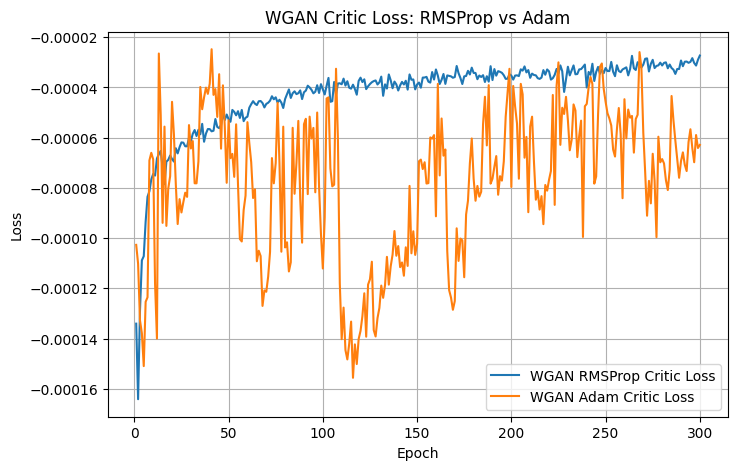

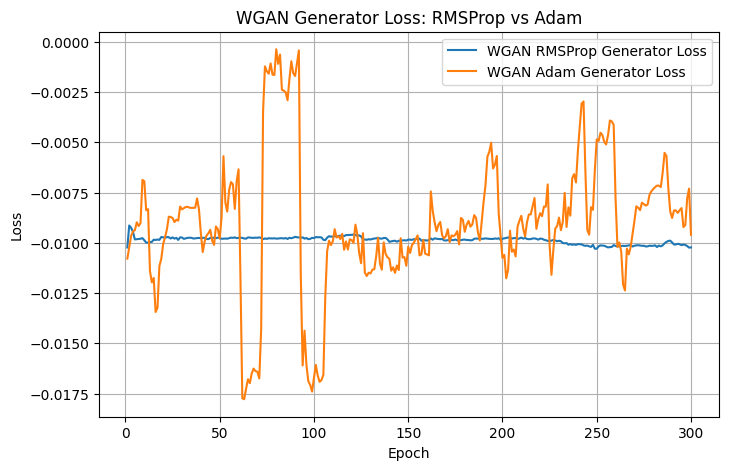

In [ ]:
def plot_wgan_optimizer_comparison(rms_g_losses, rms_c_losses, adam_g_losses, adam_c_losses):
    epochs = np.arange(1, len(rms_g_losses) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, rms_c_losses, label="WGAN RMSProp Critic Loss")
    plt.plot(epochs, adam_c_losses, label="WGAN Adam Critic Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("WGAN Critic Loss: RMSProp vs Adam")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, rms_g_losses, label="WGAN RMSProp Generator Loss")
    plt.plot(epochs, adam_g_losses, label="WGAN Adam Generator Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("WGAN Generator Loss: RMSProp vs Adam")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_wgan_optimizer_comparison(
    wgan_g_losses,
    wgan_c_losses,
    wgan_adam_g_losses,
    wgan_adam_c_losses
)

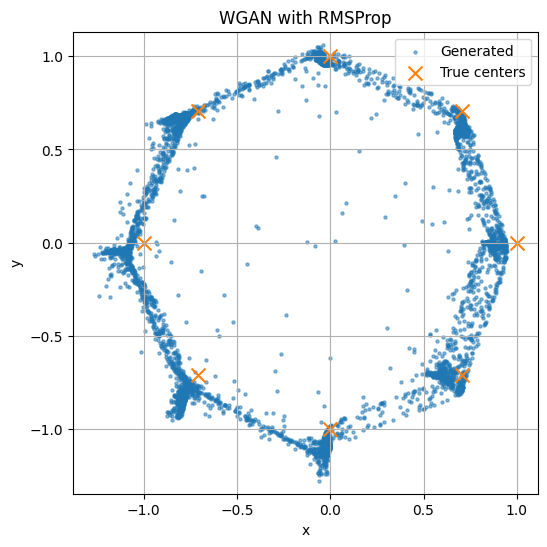

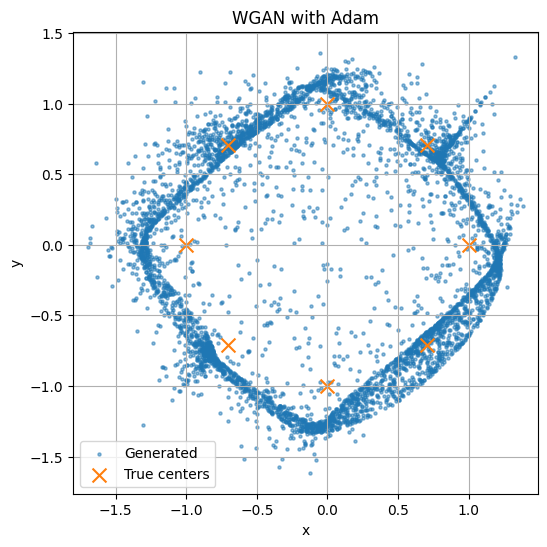

In [ ]:
def generate_samples(G, n_samples=5000, z_dim=2):
    G.eval()
    with torch.no_grad():
        z = torch.randn(n_samples, z_dim, device=device)
        samples = G(z).cpu().numpy()
    return samples

def get_true_centers(radius=1.0, n_modes=8):
    angles = np.linspace(0, 2*np.pi, n_modes, endpoint=False)
    centers = np.stack([radius*np.cos(angles), radius*np.sin(angles)], axis=1)
    return centers

def plot_generated_scatter(samples, centers=None, title="Generated Samples"):
    plt.figure(figsize=(6, 6))
    plt.scatter(samples[:, 0], samples[:, 1], s=5, alpha=0.5, label="Generated")
    if centers is not None:
        plt.scatter(centers[:, 0], centers[:, 1], s=100, marker='x', label="True centers")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.legend()
    plt.axis("equal")
    plt.grid(True)
    plt.show()

centers = get_true_centers()

samples_rms = generate_samples(wgan_G, n_samples=5000, z_dim=2)
samples_adam = generate_samples(wgan_adam_G, n_samples=5000, z_dim=2)

plot_generated_scatter(samples_rms, centers, title="WGAN with RMSProp")
plot_generated_scatter(samples_adam, centers, title="WGAN with Adam")

In [ ]:
def compute_mode_coverage(samples, centers, threshold=0.10):
    covered = 0
    per_mode = []
    for c in centers:
        dists = np.linalg.norm(samples - c, axis=1)
        hit = np.any(dists < threshold)
        per_mode.append(hit)
        if hit:
            covered += 1
    return covered, per_mode

covered_rms, per_mode_rms = compute_mode_coverage(samples_rms, centers, threshold=0.10)
covered_adam, per_mode_adam = compute_mode_coverage(samples_adam, centers, threshold=0.10)

print("WGAN with RMSProp: mode coverage =", covered_rms, "/ 8")
print("Per mode:", per_mode_rms)

print("\nWGAN with Adam: mode coverage =", covered_adam, "/ 8")
print("Per mode:", per_mode_adam)

WGAN with RMSProp: mode coverage = 8 / 8
Per mode: [np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_]

WGAN with Adam: mode coverage = 8 / 8
Per mode: [np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_]


Report 4(c)

For this part, I added one more experiment beyond the original WGAN setup so I could compare WGAN trained with RMSProp and WGAN trained with Adam, as asked in the homework. The WGAN objective, critic structure, batch size, number of epochs, 5 critic updates per generator update, and weight clipping at 0.01 were all kept the same. The main change was just the optimizer. In this additional experiment, I trained the WGAN with Adam using a learning rate of one times ten to the power of minus four instead of RMSProp.

This comparison was useful because it isolated the effect of optimizer choice on training behavior in the 2D Gaussian ring setting. Based on the results in the notebook, both the RMSProp version and the Adam version achieved full mode coverage, meaning both of them recovered all 8 Gaussian modes. So in that sense, both optimizers worked.

However, the overall training behavior was not exactly the same. The WGAN trained with RMSProp gave a cleaner ring structure and the generated samples looked more evenly distributed around the circle. Its loss curves also looked more stable. On the other hand, the WGAN trained with Adam showed more oscillation in the loss curves, and the generated samples looked a little more spread out in the scatter plot. So even though both versions reached 8 out of 8 mode coverage, the RMSProp version looked more stable in this experiment. Based on these results, RMSProp worked better than Adam for this WGAN setup on the 2D Gaussian ring dataset.

5. [30 points] Evaluation and Comparison
(a) [15 points] Visualize the generated samples for both models. Your plot should recapture Figure 2 in the
abovementioned paper for the vanilla GAN and the WGAN (not the unrolled GAN). You will visualize
both the samples as a scatter plot as well as using KDE as done in the paper.

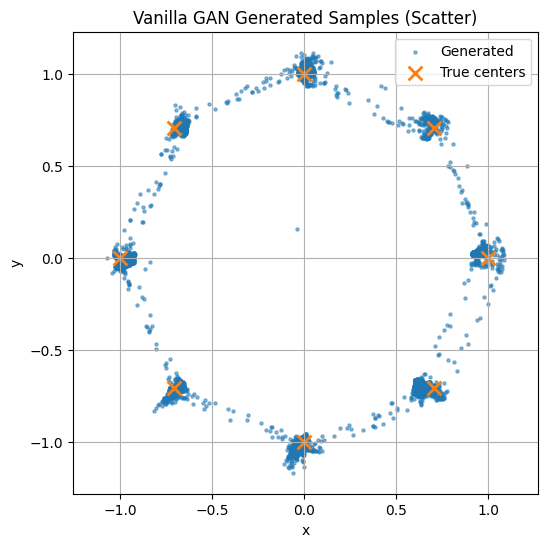

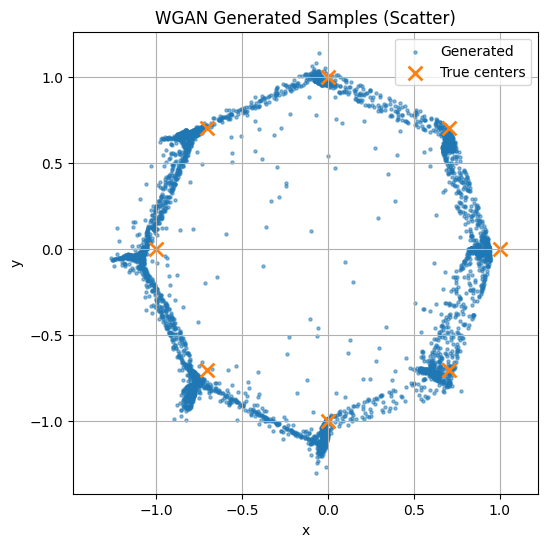

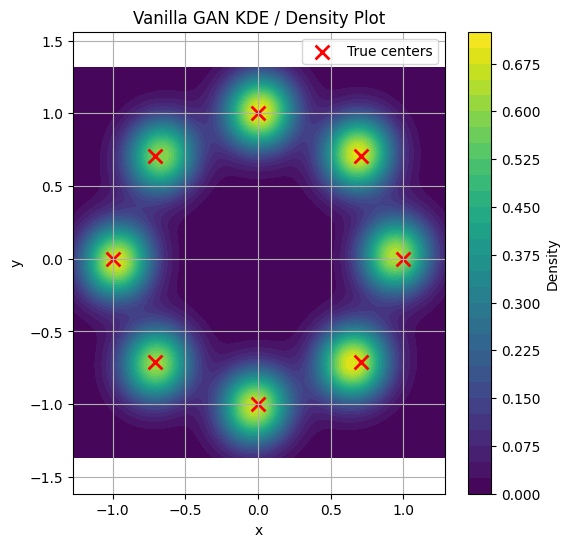

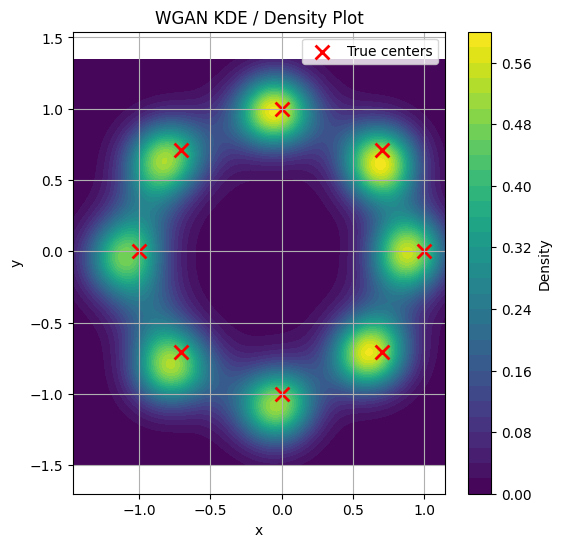

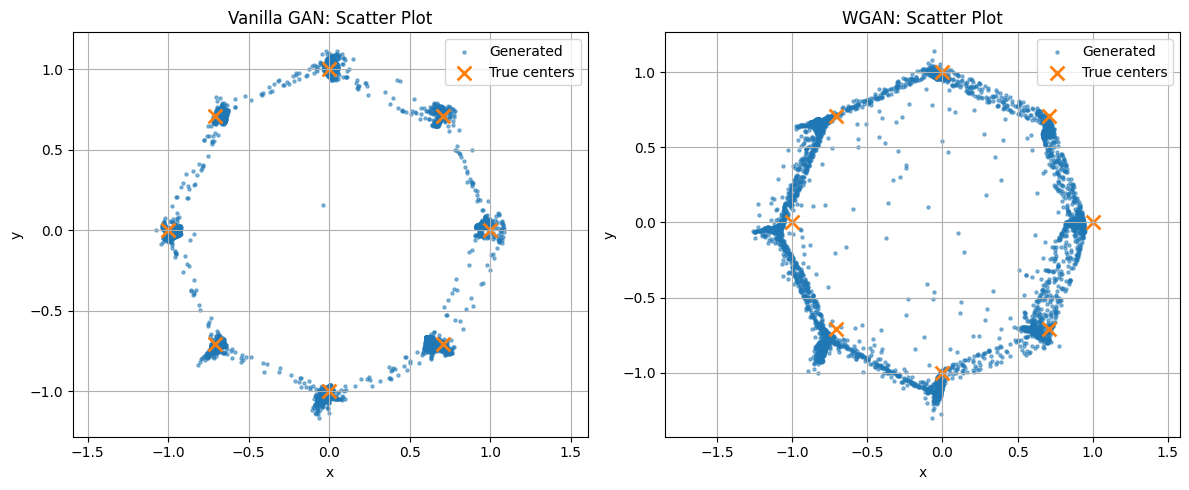

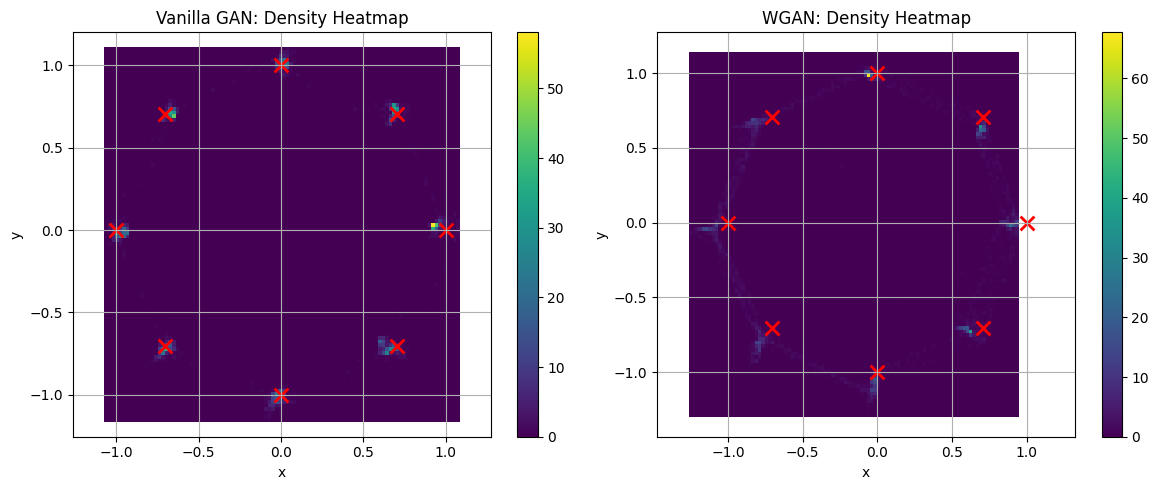

In [ ]:
# ============================================================
# HW3 - Problem 5(a)
# Visualize generated samples for Vanilla GAN and WGAN
# Includes scatter plots and KDE-style density plots
# Reusable for 5(b) and 5(c)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import torch

# Optional smooth KDE
try:
    from scipy.stats import gaussian_kde
    SCIPY_AVAILABLE = True
except:
    SCIPY_AVAILABLE = False


# ============================================================
# HELPERS
# ============================================================
def get_true_centers(radius=1.0, n_modes=8):
    angles = np.linspace(0, 2 * np.pi, n_modes, endpoint=False)
    centers = np.stack(
        [radius * np.cos(angles), radius * np.sin(angles)],
        axis=1
    )
    return centers


def generate_samples(G, n_samples=5000, z_dim=2, device=device):
    """
    Generate samples from a trained generator.
    """
    G.eval()
    with torch.no_grad():
        z = torch.randn(n_samples, z_dim, device=device)
        samples = G(z).cpu().numpy()
    return samples


def plot_generated_scatter(samples, centers=None, title="Generated Samples"):
    """
    Scatter plot of generated samples with true mode centers.
    """
    plt.figure(figsize=(6, 6))
    plt.scatter(samples[:, 0], samples[:, 1], s=5, alpha=0.5, label="Generated")
    if centers is not None:
        plt.scatter(
            centers[:, 0], centers[:, 1],
            s=100, marker='x', linewidths=2, label="True centers"
        )
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.legend()
    plt.axis("equal")
    plt.grid(True)
    plt.show()


def plot_density_hist2d(samples, centers=None, bins=100, title="Density Heatmap"):
    """
    KDE-style density visualization using a 2D histogram.
    This works without extra packages.
    """
    plt.figure(figsize=(6, 6))
    plt.hist2d(samples[:, 0], samples[:, 1], bins=bins, density=True)
    plt.colorbar(label="Density")
    if centers is not None:
        plt.scatter(
            centers[:, 0], centers[:, 1],
            s=100, marker='x', linewidths=2, color='red', label="True centers"
        )
        plt.legend()
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.axis("equal")
    plt.grid(True)
    plt.show()


def plot_density_kde(samples, centers=None, title="KDE Density Plot", gridsize=200):
    """
    Smooth KDE contour/heatmap using scipy if available.
    Falls back to hist2d if scipy is unavailable.
    """
    if not SCIPY_AVAILABLE:
        print("scipy not available, falling back to 2D histogram density plot.")
        plot_density_hist2d(samples, centers=centers, bins=100, title=title + " (hist2d fallback)")
        return

    x = samples[:, 0]
    y = samples[:, 1]

    xmin, xmax = x.min() - 0.2, x.max() + 0.2
    ymin, ymax = y.min() - 0.2, y.max() + 0.2

    xx, yy = np.meshgrid(
        np.linspace(xmin, xmax, gridsize),
        np.linspace(ymin, ymax, gridsize)
    )

    positions = np.vstack([xx.ravel(), yy.ravel()])
    values = np.vstack([x, y])
    kde = gaussian_kde(values)
    zz = np.reshape(kde(positions).T, xx.shape)

    plt.figure(figsize=(6, 6))
    plt.contourf(xx, yy, zz, levels=30)
    plt.colorbar(label="Density")

    if centers is not None:
        plt.scatter(
            centers[:, 0], centers[:, 1],
            s=100, marker='x', linewidths=2, color='red', label="True centers"
        )
        plt.legend()

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.axis("equal")
    plt.grid(True)
    plt.show()


def compare_models_scatter(vanilla_samples, wgan_samples, centers=None):
    """
    Side-by-side scatter comparison for Vanilla GAN and WGAN.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].scatter(vanilla_samples[:, 0], vanilla_samples[:, 1], s=5, alpha=0.5, label="Generated")
    if centers is not None:
        axes[0].scatter(centers[:, 0], centers[:, 1], s=100, marker='x', linewidths=2, label="True centers")
    axes[0].set_title("Vanilla GAN: Scatter Plot")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")
    axes[0].axis("equal")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].scatter(wgan_samples[:, 0], wgan_samples[:, 1], s=5, alpha=0.5, label="Generated")
    if centers is not None:
        axes[1].scatter(centers[:, 0], centers[:, 1], s=100, marker='x', linewidths=2, label="True centers")
    axes[1].set_title("WGAN: Scatter Plot")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("y")
    axes[1].axis("equal")
    axes[1].grid(True)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def compare_models_density_hist2d(vanilla_samples, wgan_samples, centers=None, bins=100):
    """
    Side-by-side density heatmap comparison for Vanilla GAN and WGAN.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    h1 = axes[0].hist2d(vanilla_samples[:, 0], vanilla_samples[:, 1], bins=bins, density=True)
    fig.colorbar(h1[3], ax=axes[0])
    if centers is not None:
        axes[0].scatter(centers[:, 0], centers[:, 1], s=100, marker='x', linewidths=2, color='red')
    axes[0].set_title("Vanilla GAN: Density Heatmap")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")
    axes[0].axis("equal")
    axes[0].grid(True)

    h2 = axes[1].hist2d(wgan_samples[:, 0], wgan_samples[:, 1], bins=bins, density=True)
    fig.colorbar(h2[3], ax=axes[1])
    if centers is not None:
        axes[1].scatter(centers[:, 0], centers[:, 1], s=100, marker='x', linewidths=2, color='red')
    axes[1].set_title("WGAN: Density Heatmap")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("y")
    axes[1].axis("equal")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


# ============================================================
# GENERATE SAMPLES FROM TRAINED MODELS
# ============================================================
centers = get_true_centers(radius=1.0, n_modes=8)

vanilla_samples = generate_samples(vanilla_G, n_samples=5000, z_dim=2, device=device)
wgan_samples = generate_samples(wgan_G, n_samples=5000, z_dim=2, device=device)

# ============================================================
# INDIVIDUAL PLOTS
# ============================================================
plot_generated_scatter(vanilla_samples, centers=centers, title="Vanilla GAN Generated Samples (Scatter)")
plot_generated_scatter(wgan_samples, centers=centers, title="WGAN Generated Samples (Scatter)")

plot_density_kde(vanilla_samples, centers=centers, title="Vanilla GAN KDE / Density Plot")
plot_density_kde(wgan_samples, centers=centers, title="WGAN KDE / Density Plot")

# ============================================================
# SIDE-BY-SIDE COMPARISON PLOTS
# ============================================================
compare_models_scatter(vanilla_samples, wgan_samples, centers=centers)
compare_models_density_hist2d(vanilla_samples, wgan_samples, centers=centers, bins=100)

5(a) Report text

For this part, I will compare the trained vanilla GAN and WGAN model by generating samples from the models and visualizing them. I will be using scatter plots and density plots like KDE plots to visualize the generated samples. Since the data set is a set of 2D points instead of images, these plots will give us a good idea about the quality of the learned distribution from the data set for the two models. The scatter plots will allow us to compare the generated samples with the 8 true Gaussian center locations on the unit circle.de geometry, but they represent it differently.

From the plots in the notebook, it was observed that both models were successful in capturing the overall 8-mode ring structure. For the vanilla GAN, the plots looked a bit more tightly packed around the respective Gaussian modes. Hence, the modes looked a bit sharper. For the WGAN model, the plots were also similar to the ring structure. However, the plots looked smoother as they were a bit broader for the respective modes. The KDE plots also depicted similar results. For the vanilla GAN model, the high-density regions looked a bit more concentrated towards the respective modes. For the WGAN model, the high-density regions looked smoother along the ring. Thus, it can be inferred that both models were successful in capturing the overall ring structure for the 2D Gaussian mixture. However, the vanilla GAN model looked a bit more mode-centered, whereas the WGAN model looked smoother along the ring.

b) [10 points] Compute and compare mode coverage (i.e., how many of the 8 Gaussians are recovered).

Vanilla GAN: mode coverage = 8 / 8
Per mode covered: [np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_]
Samples near each mode: [575, 616, 619, 527, 609, 549, 570, 524]

WGAN: mode coverage = 8 / 8
Per mode covered: [np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.True_]
Samples near each mode: [162, 336, 481, 124, 122, 127, 240, 278]



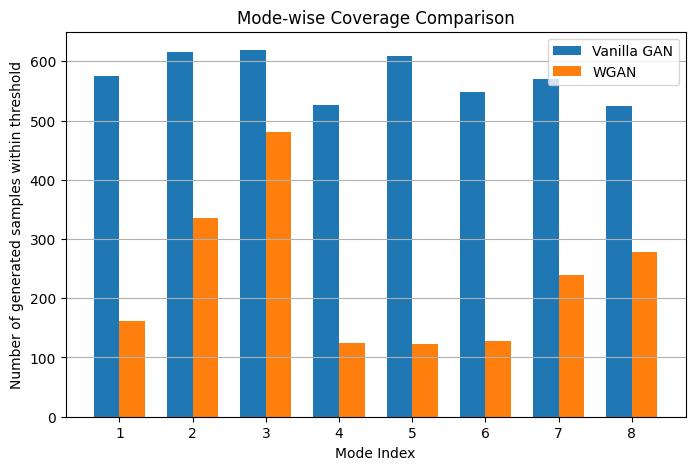

In [ ]:
# ============================================================
# HW3 - Problem 5(b)
# Compute and compare mode coverage for Vanilla GAN and WGAN
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

def get_true_centers(radius=1.0, n_modes=8):
    angles = np.linspace(0, 2 * np.pi, n_modes, endpoint=False)
    centers = np.stack(
        [radius * np.cos(angles), radius * np.sin(angles)],
        axis=1
    )
    return centers


def compute_mode_coverage(samples, centers, threshold=0.10):
    """
    A mode is counted as covered if at least one generated sample
    lies within 'threshold' Euclidean distance of the true center.
    """
    covered = 0
    per_mode = []
    counts_per_mode = []

    for c in centers:
        dists = np.linalg.norm(samples - c, axis=1)
        hits = dists < threshold
        hit = np.any(hits)

        per_mode.append(hit)
        counts_per_mode.append(int(np.sum(hits)))

        if hit:
            covered += 1

    return covered, per_mode, counts_per_mode


def print_mode_coverage_results(model_name, covered, per_mode, counts_per_mode):
    print(f"{model_name}: mode coverage = {covered} / 8")
    print("Per mode covered:", per_mode)
    print("Samples near each mode:", counts_per_mode)
    print()


def plot_mode_hit_counts(vanilla_counts, wgan_counts):
    mode_ids = np.arange(1, 9)
    width = 0.35

    plt.figure(figsize=(8, 5))
    plt.bar(mode_ids - width/2, vanilla_counts, width=width, label="Vanilla GAN")
    plt.bar(mode_ids + width/2, wgan_counts, width=width, label="WGAN")
    plt.xlabel("Mode Index")
    plt.ylabel("Number of generated samples within threshold")
    plt.title("Mode-wise Coverage Comparison")
    plt.xticks(mode_ids)
    plt.legend()
    plt.grid(True, axis='y')
    plt.show()


# ------------------------------------------------------------
# Use already generated samples if available from 5(a)
# Otherwise regenerate them here
# ------------------------------------------------------------
try:
    vanilla_samples
except NameError:
    vanilla_samples = generate_samples(vanilla_G, n_samples=5000, z_dim=2, device=device)

try:
    wgan_samples
except NameError:
    wgan_samples = generate_samples(wgan_G, n_samples=5000, z_dim=2, device=device)

centers = get_true_centers(radius=1.0, n_modes=8)

vanilla_covered, vanilla_per_mode, vanilla_counts = compute_mode_coverage(
    vanilla_samples, centers, threshold=0.10
)

wgan_covered, wgan_per_mode, wgan_counts = compute_mode_coverage(
    wgan_samples, centers, threshold=0.10
)

print_mode_coverage_results("Vanilla GAN", vanilla_covered, vanilla_per_mode, vanilla_counts)
print_mode_coverage_results("WGAN", wgan_covered, wgan_per_mode, wgan_counts)

plot_mode_hit_counts(vanilla_counts, wgan_counts)

5(b) Report text

For this part, I implemented mode coverage in order to see if the trained models have the ability to recover the full data distribution of 8 modes. Since the homework asks us to compare the number of 8 Gaussians that have been recovered, I implemented the mode coverage specifically for the ring data. It calculates if the generated samples are close enough to the 8 true centers of the Gaussians. A mode is considered recovered if at least one of the generated samples is within a Euclidean distance of 0.10 from the center.

Using this criterion, both the vanilla GAN and the WGAN achieved full mode coverage, so both models recovered all 8 out of 8 modes in this experiment. This means neither model completely missed any of the Gaussian components on the ring.

Although the models were successful in recovering all the modes, the number of samples near each of the centers was not the same. For the vanilla GAN, the number of samples near the 8 centers was 575, 616, 619, 527, 609, 549, 570, and 524. These values indicate that the vanilla GAN put a lot of samples near the actual Gaussian centers. For the WGAN, the number of samples near the 8 centers was 162, 336, 481, 124, 122, 127, 240, and 278. These values were not as high and were not as uniform as the vanilla GAN's values, which indicates that the WGAN put the samples in a more spread-out fashion around the ring, rather than putting them closely together at the actual centers. Thus, the overall results for the two models were successful in recovering all the modes, although the vanilla GAN appeared more centered around the modes, while the WGAN appeared more centered around the overall ring.

(c) [5 points] Discuss the differences in training stability between Vanilla GAN and WGAN.

5(c) Report text

Overall, the results demonstrate that both the Vanilla GAN and the WGAN are able to learn the 2D Gaussian Mixture Ring and identify all 8 modes, but in different ways and with different stability characteristics. For the evaluation of the training stability of the GANs in this homework problem, the results will be based on the evaluation of the loss curves, the scatter plots, the KDE plots, the results of the mode coverage, and the results of the optimizer comparison in part 4(c). In this problem, since it is a synthetic dataset and not an image dataset, it is more informative to compare the results in more ways than just how well the images are produced.

Based on the results, the samples generated by the Vanilla GAN were found to be more concentrated around the individual centers of the Gaussians. This is because the scatter plots had sharper clusters around the true modes, and the KDE plots had stronger localized peaks around the individual centers. Furthermore, the loss curve of the Vanilla GAN remained relatively smooth throughout the training process. This, therefore, shows that the Vanilla GAN was successful in this experiment in learning the mode-centered structure of the data. Nevertheless, the balance between the generator and discriminator loss is typically a problem in the standard GAN, and this is one of the reasons GANs can become unstable in certain cases. Although the Vanilla GAN performed well in this experiment, this is still dependent on the balance between the generator and discriminator loss.

The WGAN, on the other hand, learned the overall structure of the ring in a more continuous manner. The samples were more spread out over the ring rather than concentrated at the exact Gaussian mode locations. This was evident in both the scatter plots and the kde/density plots. Although the critic and generator loss plots for the WGAN were flat and not very informative, the sample plots and the mode coverage results indicated that the model was still correctly learning the underlying data distribution. In fact, the WGAN was able to achieve full mode coverage as well, correctly identifying all 8 out of 8 modes.

One difference that is helpful is the way the two models dealt with the distribution. In the Vanilla GAN, there was a focus on the sharp concentration at the modes, while the WGAN focused on the smooth distribution of the entire ring manifold. This means that the Vanilla GAN was precise at the centers, while the WGAN was robust in capturing the structure of the distribution. This is because the main motivation behind the WGAN is the improvement of the training behavior through the use of the Wasserstein objective function.

The comparison of the two optimizers in part 4(c) has also helped me understand the stability of the WGAN training process. In my case, when the WGAN is trained with Adam, the quality of the samples is noisy and spread out, and the oscillations in the losses are more pronounced. However, when the WGAN is trained with the RMSProp optimizer, the quality of the samples is cleaner and ring-shaped, and the training process is more stable in general. This is understandable since the original WGAN procedure is based on RMSProp and weight clipping.

Thus, the final conclusion is that both models performed well on this 2D dataset, but in a different way. The Vanilla GAN was better at generating sharper clusters centered at the true Gaussian modes, while the WGAN was better at generating a more continuous representation of the overall ring structure. Based on the visualizations and the optimizer comparison, the WGAN with RMSProp was found to be the more stable formulation for the full geometry of the data set, while the Vanilla GAN was found to be better at generating more tightly concentrated mode-centered samples.